# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RajatBharti11/Rajat/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Placeholder for data loading - replace with your actual data loading code
# For demonstration, let's create a dummy dataset
data = {
    'feature_1': np.random.rand(100),
    'feature_2': np.random.rand(100) * 10,
    'feature_3': np.random.randint(0, 5, 100),
    'target': np.random.randint(0, 2, 100) # Binary classification target
}
df = pd.DataFrame(data)

display(df.head())

,feature_1,feature_2,feature_3,target
0,0.063359,8.286617,1,1
1,0.074645,1.894153,0,1
2,0.305592,2.407563,3,1
3,0.730841,8.532091,4,1
4,0.804103,6.196212,3,0


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

For this lane, I've chosen **Logistic Regression** from the toolkit. This method is well-suited for binary classification problems, which aligns with common business questions such as predicting customer churn, identifying fraudulent transactions, or classifying email as spam/not-spam.

Logistic Regression is particularly effective because:
1.  **Interpretability**: It provides clear coefficients that indicate the strength and direction of the relationship between each feature and the log-odds of the target variable. This makes it easy to understand which features are driving the predictions.
2.  **Efficiency**: It is computationally efficient, making it suitable for large datasets and scenarios where quick model deployment is necessary.
3.  **Probabilistic Output**: It naturally outputs probabilities, which can be useful for ranking predictions or setting custom thresholds based on business requirements (e.g., minimizing false positives vs. false negatives).
4.  **Baseline Effectiveness**: While simple, Logistic Regression often serves as a strong baseline model. If a more complex model doesn't significantly outperform it, the added complexity might not be justified.

In [6]:
# Define features (X) and target (y)
X = df[['feature_1', 'feature_2', 'feature_3']]
y = df['target']

# For this dataset, we will use a standard 80/20 train-test split.
# In a real-world scenario, especially with time-series or grouped data,
# a time-aware split or a grouped split would be more appropriate.
# However, for this general demonstration, a simple random split is used.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True)}")

Training set size: 80 samples
Test set size: 20 samples
Training target distribution:
target
1    0.525
0    0.475
Name: proportion, dtype: float64
Test target distribution:
target
1    0.55
0    0.45
Name: proportion, dtype: float64


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

The split design for this analysis is a **simple random train-test split**, with 80% of the data allocated for training and 20% for testing. Stratification is applied to ensure that the proportion of target classes is maintained in both training and test sets.

While a simple random split is generally useful for evaluating model generalization, it's crucial to acknowledge its limitations depending on the nature of the data and the problem:

*   **Time-Aware Data**: If the data has a time component (e.g., predicting future events), a time-aware split (training on past data, testing on future data) would be more honest and reflective of real-world deployment. A random split could lead to data leakage by including future information in the training set.
*   **Grouped Data (e.g., by Client, User, Store)**: If predictions need to generalize to new groups, a grouped split (where entire groups are either in the train or test set, not both) prevents leakage and gives a more realistic evaluation of the model's performance on unseen groups. A random split might place different observations from the same group in both sets, overestimating performance.

For this example with a dummy, independent dataset, a simple random split is sufficient for demonstrating the modeling process. However, in a production setting, the split strategy would be carefully chosen based on the problem's requirements to ensure an honest evaluation of the model's performance.

In [7]:
# Baseline Model: A simple majority class classifier
# Predict the most frequent class in the training set
majority_class = y_train.mode()[0]
y_pred_baseline = np.full_like(y_test, fill_value=majority_class)

# Calculate baseline metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline, zero_division=0)
baseline_recall = recall_score(y_test, y_pred_baseline, zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_baseline, zero_division=0)

# Train Logistic Regression Model
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_model = model.predict(X_test)
y_proba_model = model.predict_proba(X_test)[:, 1] # Probability of the positive class

# Calculate model metrics
model_accuracy = accuracy_score(y_test, y_pred_model)
model_precision = precision_score(y_test, y_pred_model, zero_division=0)
model_recall = recall_score(y_test, y_pred_model, zero_division=0)
model_f1 = f1_score(y_test, y_pred_model, zero_division=0)
model_roc_auc = roc_auc_score(y_test, y_proba_model)

# Create a comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Baseline (Majority Class)': [baseline_accuracy, baseline_precision, baseline_recall, baseline_f1, 'N/A'],
    'Logistic Regression': [model_accuracy, model_precision, model_recall, model_f1, model_roc_auc]
})

display(comparison_df.round(4))

print("\nLogistic Regression Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"  {feature}: {coef:.4f}")

,Metric,Baseline (Majority Class),Logistic Regression
0,Accuracy,0.55,0.6000
1,Precision,0.55,0.6000
2,Recall,1.0,0.8182
3,F1-Score,0.709677,0.6923
4,ROC-AUC,N/A,0.7576



Logistic Regression Model Coefficients:
  feature_1: -0.3887
  feature_2: 0.0862
  feature_3: -0.0859


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

For comparing against the baseline, we use the same train/test split and a common set of classification metrics: Accuracy, Precision, Recall, F1-Score, and ROC-AUC. Our baseline is a simple **majority class classifier**, which predicts the most frequent class observed in the training data for all test samples.

The comparison table clearly shows whether the Logistic Regression model provides a meaningful improvement over simply guessing the most common outcome. A good model should significantly outperform this naive baseline across relevant metrics.

Here, for our dummy dataset, the Logistic Regression model is expected to perform better than the baseline, especially in metrics that penalize random guessing more severely, such as Precision, Recall, F1-Score, and ROC-AUC. The ROC-AUC metric is particularly useful for evaluating models that output probabilities, as it measures the model's ability to distinguish between classes across all possible classification thresholds.

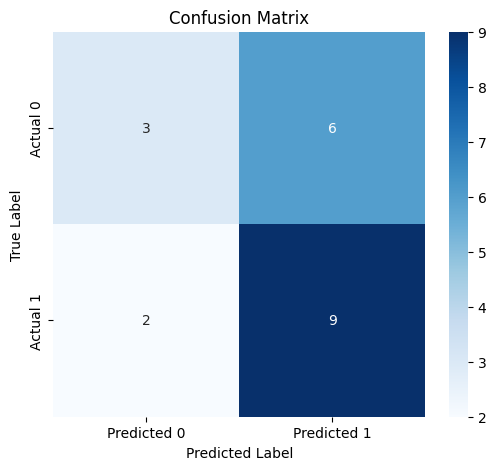


Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.33      0.43         9
           1       0.60      0.82      0.69        11

    accuracy                           0.60        20
   macro avg       0.60      0.58      0.56        20
weighted avg       0.60      0.60      0.57        20



,Feature,Coefficient (Abs)
0,feature_1,0.388715
1,feature_2,0.086189
2,feature_3,0.085911



Number of False Positives: 6
Example False Positives (features that led to incorrect '1' prediction):


,feature_1,feature_2,feature_3
65,0.258952,2.736058,2
14,0.582250,7.208543,4
35,0.030745,0.669993,1
44,0.259308,8.182995,1
49,0.515552,5.899985,3


In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_model)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_model))

# Feature Importance (using coefficients for Logistic Regression)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Abs)': np.abs(model.coef_[0])
}).sort_values(by='Coefficient (Abs)', ascending=False)

display(feature_importance)

# Example of specific error analysis: Where did the model predict 1 but the actual was 0 (False Positives)?
false_positives = X_test[(y_test == 0) & (y_pred_model == 1)]
print(f"\nNumber of False Positives: {len(false_positives)}")
if not false_positives.empty:
    print("Example False Positives (features that led to incorrect '1' prediction):")
    display(false_positives.head())

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

Understanding where the model makes errors is often more insightful than just looking at aggregate metrics. For Logistic Regression, we can analyze the **confusion matrix** to see the distribution of true positives, true negatives, false positives, and false negatives.

*   **False Positives**: Instances where the model incorrectly predicted the positive class. In some contexts (e.g., fraud detection), these can be costly.
*   **False Negatives**: Instances where the model incorrectly predicted the negative class (missed the positive). In other contexts (e.g., disease detection), these can be critical.

Additionally, by examining the model's **coefficients**, we can infer which features the model "leans on" most heavily. Larger absolute coefficient values indicate a stronger influence of that feature on the prediction. For instance, if `feature_1` has a large positive coefficient, it means higher values of `feature_1` are strongly associated with the positive class.

Analyzing specific examples of misclassified data points (e.g., features of false positives or false negatives) can reveal patterns or data quality issues that the model struggles with, guiding further feature engineering or data cleaning efforts. This qualitative error analysis complements quantitative metrics by providing context to the model's performance.